In [ ]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import wilcoxon
from scipy.stats import ttest_ind
SL = 0.05

In [ ]:
marketingData = pd.read_csv("marketing_data.csv")

In [ ]:
marketingData.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [ ]:
# Rename Income column
marketingData = marketingData.rename(columns={' Income ': 'Income'})
# Dt_Customer and Income info and describe
print(marketingData[['Dt_Customer', 'Income']].info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Dt_Customer  2240 non-null   object
 1   Income       2216 non-null   object
dtypes: object(2)
memory usage: 35.1+ KB
None


In [ ]:
 # Remove $ and comma signs from the Income column
marketingData['Income'] = marketingData['Income'].str.replace('$', '').str.replace(',', '')

In [ ]:
marketingData['Income']

0       84835.00 
1       57091.00 
2       67267.00 
3       32474.00 
4       21474.00 
          ...    
2235    66476.00 
2236    31056.00 
2237    46310.00 
2238    65819.00 
2239    94871.00 
Name: Income, Length: 2240, dtype: object

In [ ]:
# Conduct missing value imputation
marketingData.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [ ]:
marketingData['Education'].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [ ]:
# Clean up missing column by grouping ins and Marital_Statu Education as per Domain Expert
marketingData['Marital_Status'].unique()
marketingData['Income'] = marketingData['Income'].fillna(marketingData.groupby('Education')['Marital_Status'].transform(lambda x: 10000))

In [ ]:
# verify after fill missing values
marketingData.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64

In [ ]:
# Create variables to represent the total number of children, age, and total spending
marketingData['total_children'] = marketingData['Kidhome'] + marketingData['Teenhome']
marketingData['age'] = 2024 - marketingData['Year_Birth']
marketingData['total_spending'] = marketingData['MntWines'] + marketingData['MntFruits'] + marketingData['MntMeatProducts'] + marketingData['MntFishProducts'] + marketingData['MntSweetProducts'] + marketingData['MntGoldProds']
marketingData.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,total_children,age,total_spending
0,1826,1970,Graduation,Divorced,84835.00,0,0,6/16/14,0,189,...,0,0,0,0,1,0,SP,0,54,1190
1,1,1961,Graduation,Single,57091.00,0,0,6/15/14,0,464,...,0,0,0,1,1,0,CA,0,63,577
2,10476,1958,Graduation,Married,67267.00,0,1,5/13/14,0,134,...,0,0,0,0,0,0,US,1,66,251
3,1386,1967,Graduation,Together,32474.00,1,1,5/11/14,0,10,...,0,0,0,0,0,0,AUS,2,57,11
4,5371,1989,Graduation,Single,21474.00,1,0,4/8/14,0,6,...,0,0,0,0,1,0,SP,1,35,91


In [ ]:
#Derive the total purchases from the number of transactions across the three channels.
marketingData['total_purchases'] = marketingData['NumDealsPurchases'] + marketingData['NumWebPurchases'] + marketingData['NumCatalogPurchases']
marketingData.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,total_children,age,total_spending,total_purchases
0,1826,1970,Graduation,Divorced,84835.00,0,0,6/16/14,0,189,...,0,0,0,1,0,SP,0,54,1190,9
1,1,1961,Graduation,Single,57091.00,0,0,6/15/14,0,464,...,0,0,1,1,0,CA,0,63,577,11
2,10476,1958,Graduation,Married,67267.00,0,1,5/13/14,0,134,...,0,0,0,0,0,US,1,66,251,6
3,1386,1967,Graduation,Together,32474.00,1,1,5/11/14,0,10,...,0,0,0,0,0,AUS,2,57,11,2
4,5371,1989,Graduation,Single,21474.00,1,0,4/8/14,0,6,...,0,0,0,1,0,SP,1,35,91,6


<Axes: xlabel='total_children', ylabel='Count'>

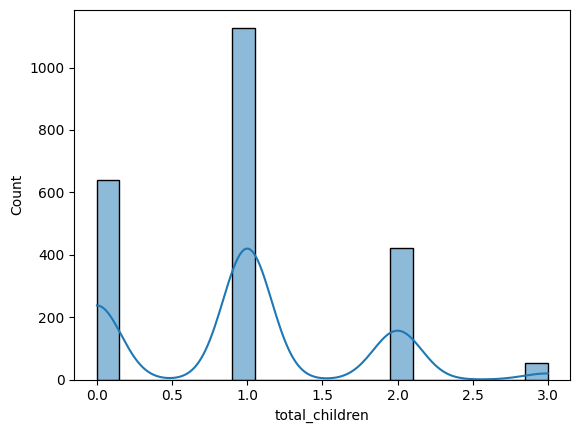

In [ ]:
# Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed
# Continuous ND columns: total_children, age, total_spending, total_purchases, Income
sns.histplot(marketingData['total_children'], kde=True)


<Axes: ylabel='total_children'>

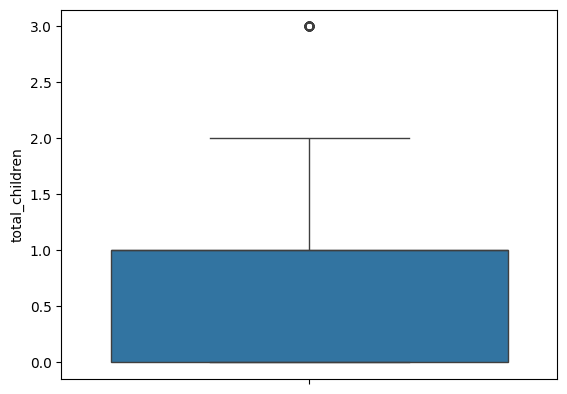

In [ ]:
# Box plot
sns.boxplot(marketingData['total_children'])

In [ ]:
marketingData['total_children'].describe()

count    2240.000000
mean        0.950446
std         0.751803
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: total_children, dtype: float64

In [ ]:
# Here outliers is there, so we need to remove outliers
def removeTheOutLiers(col):
  sorted(col)

  Q1,Q3 =  np.percentile(col,[25,75])

  #finding the IQR
  IQR = Q3-Q1

  #Finding the lowerRage and upperRange
  lowerRage = Q1 - (1.5*IQR)
  upperRange = Q3 + (1.5*IQR)

  return lowerRage,upperRange


In [ ]:
lr,ur = removeTheOutLiers(marketingData['total_children'])

In [ ]:
marketingData = marketingData[(marketingData['total_children']>=lr) & (marketingData['total_children']<=ur)]

<Axes: xlabel='total_children', ylabel='Count'>

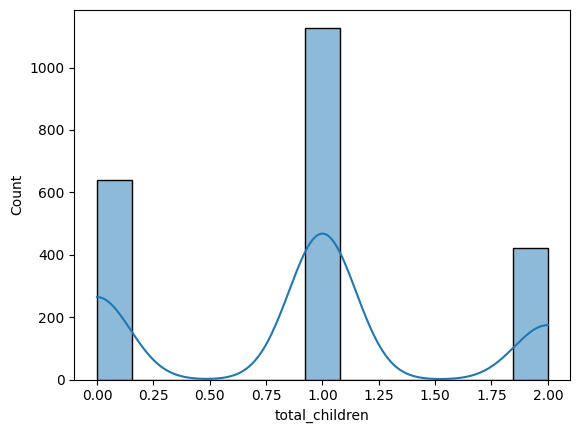

In [ ]:
# Histogram plot post removal of outliers
sns.histplot(marketingData['total_children'], kde=True)

<Axes: ylabel='total_children'>

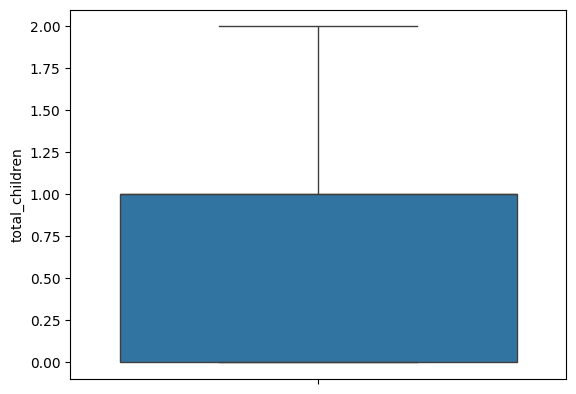

In [ ]:
sns.boxplot(marketingData['total_children'])

In [ ]:
# Remove outliers for Age column
marketingData['age'].describe()

count    2187.000000
mean       55.043896
std        12.013217
min        28.000000
25%        46.000000
50%        54.000000
75%        65.000000
max       131.000000
Name: age, dtype: float64

<Axes: ylabel='age'>

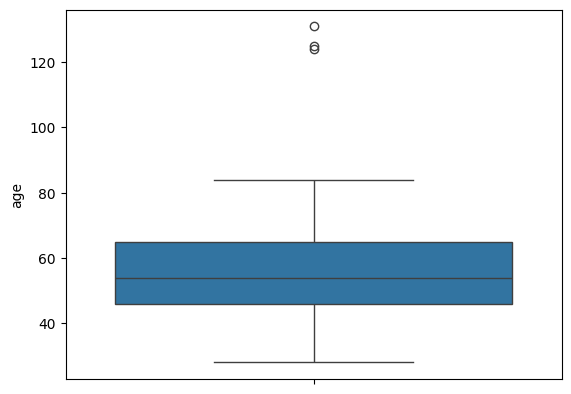

In [ ]:
# here mean value is 55 and it is having outliers
sns.boxplot(marketingData['age'])

In [ ]:
# Outliers can be clealy visible using boxplot, so we need to remove
lr,ur = removeTheOutLiers(marketingData['age'])

In [ ]:
marketingData = marketingData[(marketingData['age']>=lr) & (marketingData['age']<=ur)]

<Axes: xlabel='age', ylabel='Count'>

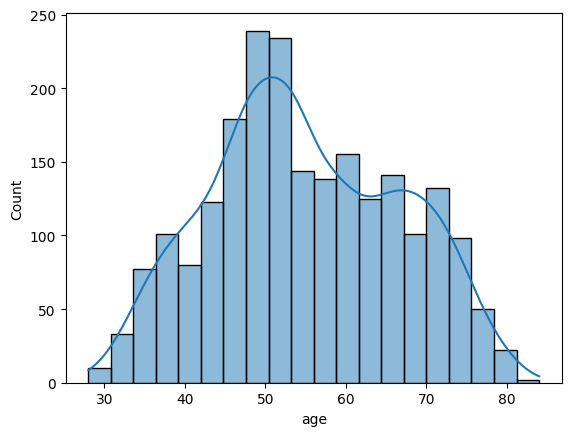

In [ ]:
sns.histplot(marketingData['age'], kde=True)

<Axes: ylabel='age'>

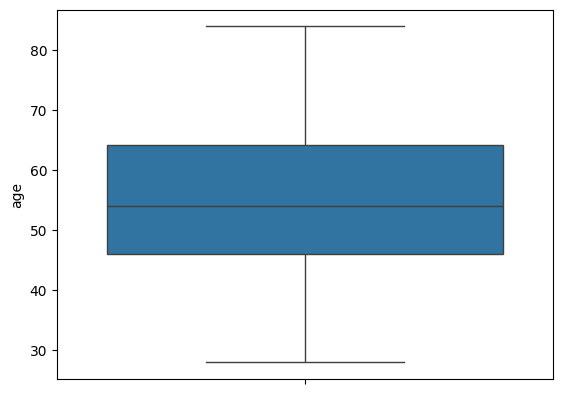

In [ ]:
sns.boxplot(marketingData['age'])

<Axes: ylabel='total_spending'>

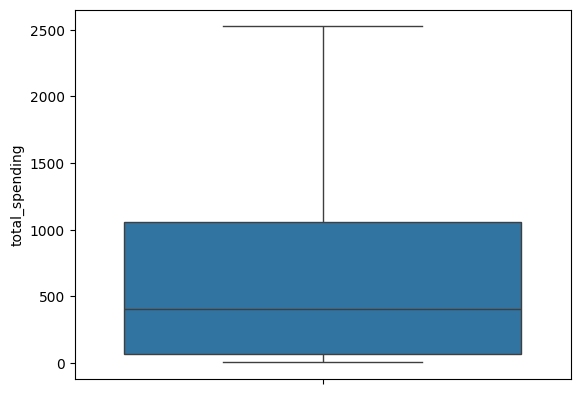

In [ ]:
#  To check for total_spending
sns.boxplot(marketingData['total_spending'])

<Axes: xlabel='total_spending', ylabel='Count'>

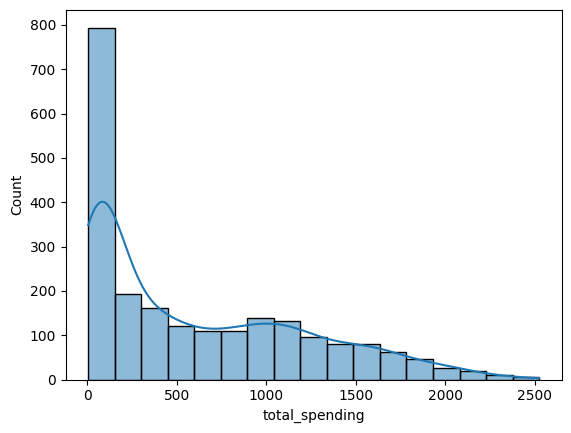

In [ ]:
sns.histplot(marketingData['total_spending'], kde=True)

In [ ]:
# Here no outliers, no need to remove but still we can verify
lr,ur = removeTheOutLiers(marketingData['total_spending'])
marketingData = marketingData[(marketingData['total_spending']>=lr) & (marketingData['total_spending']<=ur)]

In [ ]:
lr,ur

(-1407.125, 2531.875)

<Axes: xlabel='total_purchases', ylabel='Count'>

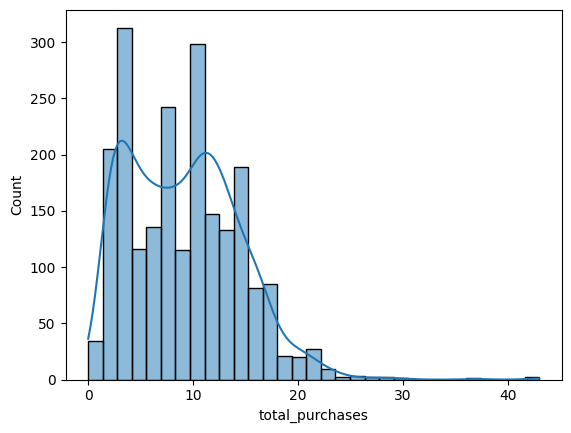

In [ ]:
# Test for total_purchase
sns.histplot(marketingData['total_purchases'], kde=True)

In [ ]:
marketingData['total_purchases'].describe()

count    2184.000000
mean        9.109432
std         5.321838
min         0.000000
25%         4.000000
50%         9.000000
75%        13.000000
max        43.000000
Name: total_purchases, dtype: float64

In [ ]:
# Here outliers is there
lr,ur = removeTheOutLiers(marketingData['total_purchases'])
marketingData = marketingData[(marketingData['total_purchases']>=lr) & (marketingData['total_purchases']<=ur)]

<Axes: xlabel='total_purchases', ylabel='Count'>

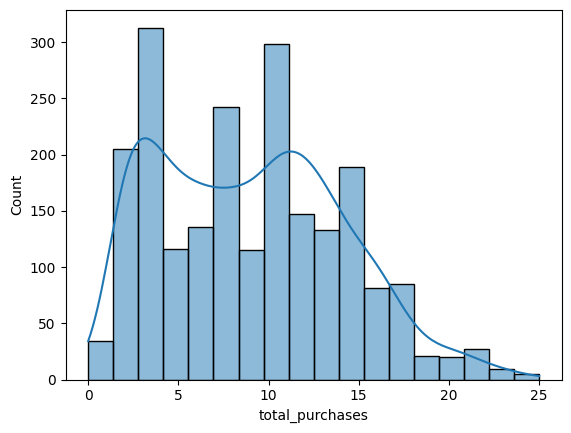

In [ ]:
sns.histplot(marketingData['total_purchases'], kde=True)

<Axes: ylabel='total_purchases'>

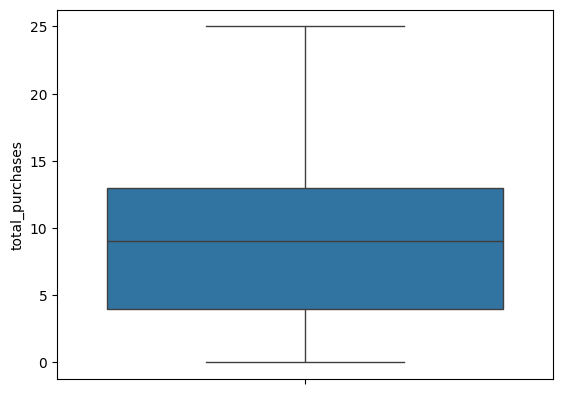

In [ ]:
sns.boxplot(marketingData['total_purchases'])

In [ ]:
# To check for Income
marketingData['Income'].describe()

count      2176
unique     1921
top       10000
freq         20
Name: Income, dtype: int64

In [ ]:
# convert income column float to int type
marketingData['Income'] = pd.to_numeric(marketingData['Income'])
marketingData['Income'] = marketingData['Income'].astype(int)


<Axes: xlabel='Income', ylabel='Count'>

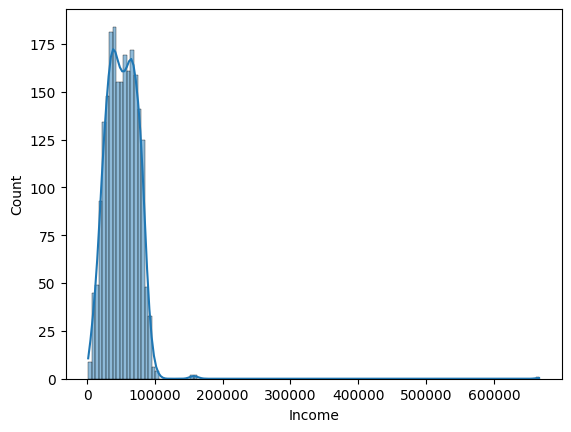

In [ ]:
sns.histplot(marketingData['Income'], kde=True)

<Axes: ylabel='Income'>

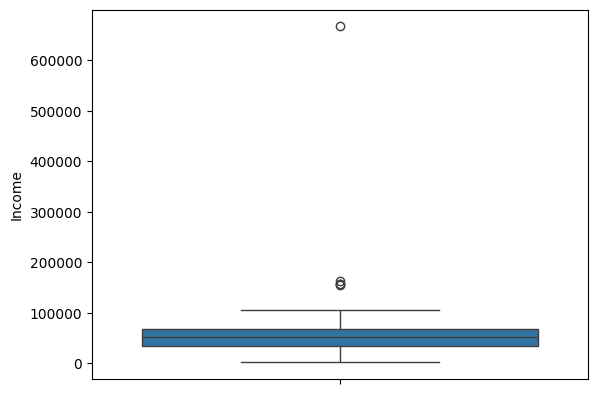

In [ ]:
sns.boxplot(marketingData['Income'])

In [ ]:
lr,ur = removeTheOutLiers(marketingData['Income'])
marketingData = marketingData[(marketingData['Income']>=lr) & (marketingData['Income']<=ur)]

<Axes: ylabel='Income'>

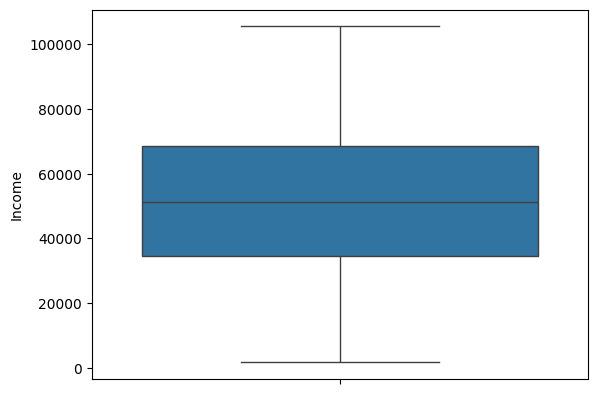

In [ ]:
sns.boxplot(marketingData['Income'])

In [ ]:
marketingData['Education'].value_counts()

Education
Graduation    1096
PhD            463
Master         361
2n Cycle       197
Basic           54
Name: count, dtype: int64

In [ ]:
# Test the following hypotheses:
# a. Older individuals may not possess the same level of technological
# proficiency and may, therefore, lean toward traditional in-store shopping
# preferences
marketingData['InStore_Preference'] = marketingData['NumStorePurchases'] / marketingData['total_purchases']
marketingData['InStore_Preference']


0       0.666667
1       0.636364
2       0.833333
3       1.000000
4       0.333333
          ...   
2235    1.222222
2236    1.500000
2237    0.555556
2238    1.000000
2239    0.285714
Name: InStore_Preference, Length: 2171, dtype: float64

In [ ]:
marketingData['InStore_Preference'].isna().sum()

2

In [ ]:
marketingData['InStore_Preference'].fillna(marketingData['InStore_Preference'].mean(), inplace=True)

In [ ]:
marketingData['InStore_Preference']

0       0.666667
1       0.636364
2       0.833333
3       1.000000
4       0.333333
          ...   
2235    1.222222
2236    1.500000
2237    0.555556
2238    1.000000
2239    0.285714
Name: InStore_Preference, Length: 2171, dtype: float64

In [ ]:
np.isinf(marketingData['InStore_Preference']).any()

True

In [ ]:
def replaceInfiniteValues(col):
  col = col.replace([np.inf, -np.inf], np.nan)
  return col
marketingData['InStore_Preference'] = replaceInfiniteValues(marketingData['InStore_Preference'])

In [ ]:
np.isinf(marketingData['InStore_Preference']).any()

False

In [ ]:
marketingData['InStore_Preference'].isna().sum()

4

In [ ]:
marketingData['InStore_Preference'].fillna(marketingData['InStore_Preference'].mean(), inplace=True)

In [ ]:
marketingData['InStore_Preference'].isna().sum()

0

In [ ]:
marketingData['InStore_Preference'] = marketingData['InStore_Preference'].astype(int)

In [ ]:
corr, pvalue = pearsonr(marketingData['age'], marketingData['InStore_Preference'])
print(corr, pvalue)
if pvalue <= SL:
  print("linear Relationship")
  print("Corr value: ",corr)
else:
  print("No linear Relationship")

-0.08148973856654117 0.00014407361716154514
linear Relationship
Corr value:  -0.08148973856654117


<Axes: xlabel='age', ylabel='InStore_Preference'>

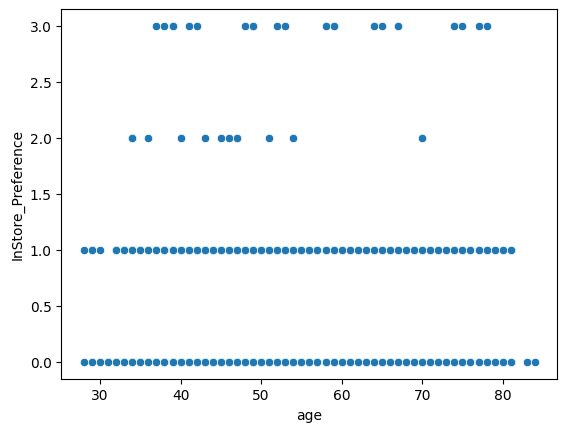

In [ ]:
# To perform Normality Test
sns.scatterplot(x=marketingData['age'], y=marketingData['InStore_Preference'])

In [ ]:
# To check if InStore_Preference is Normally Distributed
_,pvalue = shapiro(marketingData['InStore_Preference'])

if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
# To check if Age is Normally Distributed
_,pvalue = shapiro(marketingData['age'])

if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
# since one column is not normally distributed then go for  Non-parametric hypothesis
_,pvalue = wilcoxon(marketingData['age'], marketingData['InStore_Preference'])

if pvalue<=SL:
  print("PRESERVE both of them")
else:
  print("ELIMINATE one of them")

PRESERVE both of them


<Axes: xlabel='Online_Preference', ylabel='total_purchases'>

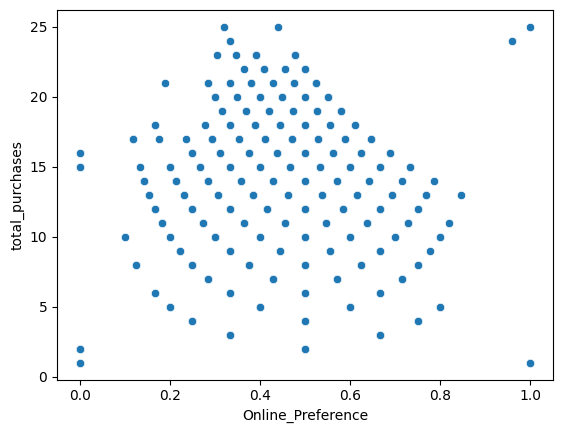

In [ ]:
# Customers with children likely experience time constraints, making online
# shopping a more convenient option
marketingData['Online_Preference'] = marketingData['NumWebPurchases'] / marketingData['total_purchases']

sns.scatterplot(x=marketingData['Online_Preference'], y=marketingData['total_purchases'])

In [ ]:
marketingData['Online_Preference'].isna().sum()

4

In [ ]:
marketingData['Online_Preference'].fillna(marketingData['Online_Preference'].mean(), inplace=True)
marketingData['Online_Preference'] = marketingData['Online_Preference'].astype(int)

In [ ]:
corr, pvalue = pearsonr(marketingData['total_children'], marketingData['Online_Preference'])
print(corr, pvalue)
if pvalue <= SL:
  print("linear Relationship")
  print("Corr value: ",corr)
else:
  print("No linear Relationship")

-0.01270276950880079 0.5541481325489684
No linear Relationship


In [ ]:
_,pvalue = shapiro(marketingData['total_children'])

if pvalue >= SL:
  print(" NORMALLY DISTRIBUTED")
else:
  print("NORMALLY DISTRIBUTED")

NORMALLY DISTRIBUTED


In [ ]:
_,pvalue = shapiro(marketingData['Online_Preference'])

if pvalue >= SL:
  print(" NORMALLY DISTRIBUTED")
else:
  print("NORMALLY DISTRIBUTED")

NORMALLY DISTRIBUTED


In [ ]:
# since one both are normally distributed then go for  parametric hypothesis
_,pvalue = ttest_ind(marketingData['total_children'], marketingData['Online_Preference'])
if pvalue<=SL:
  print("PRESERVE both of them")
else:
  print("ELIMINATE one of them")

PRESERVE both of them


<Axes: xlabel='NumWebPurchases', ylabel='NumStorePurchases'>

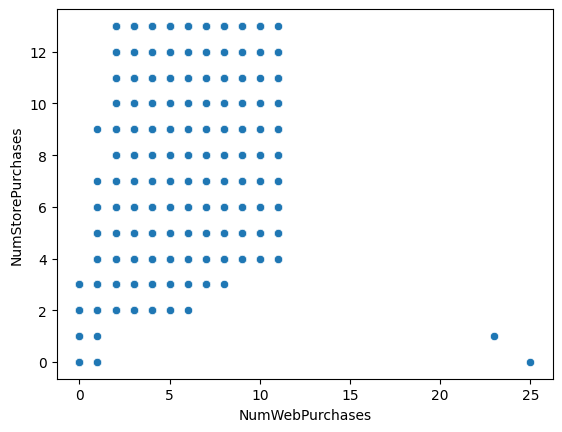

In [ ]:
# Sales at physical stores may face the risk of cannibalization by alternative
# distribution channels.
sns.scatterplot(x='NumWebPurchases', y='NumStorePurchases', data=marketingData)

In [ ]:
corr, pvalue = pearsonr(marketingData['NumWebPurchases'], marketingData['NumStorePurchases'])
print(corr, pvalue)
if pvalue <= SL:
  print("linear Relationship")
  print("Corr value: ",corr)
else:
  print("No linear Relationship")


0.5274905165669456 8.589246840019081e-156
linear Relationship
Corr value:  0.5274905165669456


In [ ]:
_,pvalue = shapiro(marketingData['NumWebPurchases'])
if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
_,pvalue = shapiro(marketingData['NumStorePurchases'])

if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
# since one column is not normally distributed then go for  Non-parametric hypothesis
_,pvalue = wilcoxon(marketingData['NumWebPurchases'], marketingData['NumStorePurchases'])

if pvalue<=SL:
  print("PRESERVE both of them")
else:
  print("ELIMINATE one of them")

PRESERVE both of them


In [ ]:
# # Does the United States significantly outperform the rest of the world in total purchase volumes?
us_data = marketingData[marketingData['Country'] == 'US']
marketingData['us_total_purchases'] = us_data['total_purchases']

rest_data = marketingData[marketingData['Country'] != 'US']
marketingData['rest_total_purchases'] = rest_data['total_purchases']


In [ ]:
marketingData['us_total_purchases'].isna().sum()


2067

In [ ]:
marketingData['us_total_purchases'] = marketingData['us_total_purchases'].fillna(marketingData['us_total_purchases'].mean())
marketingData['us_total_purchases'].isna().sum()

0

In [ ]:
marketingData['rest_total_purchases'].isna().sum()

104

In [ ]:
marketingData['rest_total_purchases'] = marketingData['rest_total_purchases'].fillna(marketingData['rest_total_purchases'].mean())
marketingData['rest_total_purchases'].isna().sum()

0

In [ ]:
corr, pvalue = pearsonr(marketingData['us_total_purchases'], marketingData['rest_total_purchases'])
print(corr, pvalue)
if pvalue <= SL:
  print("linear Relationship")
  print("Corr value: ",corr)
else:
  print("No linear Relationship")

-9.003722490010328e-33 1.0000000000000013
No linear Relationship


<Axes: xlabel='us_total_purchases', ylabel='rest_total_purchases'>

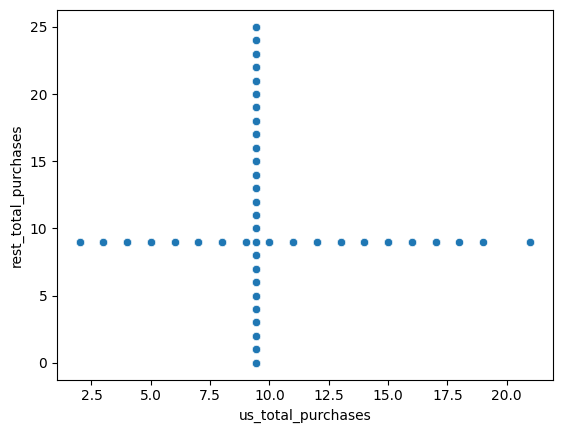

In [ ]:
sns.scatterplot(x='us_total_purchases', y='rest_total_purchases', data=marketingData)

In [ ]:
_,pvalue = shapiro(marketingData['us_total_purchases'])
if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
_,pvalue = shapiro(marketingData['rest_total_purchases'])

if pvalue >= SL:
  print("NORMALLY DISTRIBUTED")
else:
  print("NOT NORMALLY DISTRIBUTED")

NOT NORMALLY DISTRIBUTED


In [ ]:
# since both are not normally distributed then go for  Non-parametric hypothesis
_,pvalue = wilcoxon(marketingData['rest_total_purchases'], marketingData['us_total_purchases'])

if pvalue<=SL:
  print("PRESERVE both of them")
else:
  print("ELIMINATE one of them")

PRESERVE both of them


In [ ]:
# 8. Use appropriate visualization to help analyze the following:
# a. Identify the top-performing products and those with the lowest revenue
# generated.

top_performing_products = marketingData[
    ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
    ].sum()
print(top_performing_products)

MntWines            669215
MntFruits            58297
MntMeatProducts     362541
MntFishProducts      83283
MntSweetProducts     59446
MntGoldProds         96864
dtype: int64


<Axes: xlabel='None'>

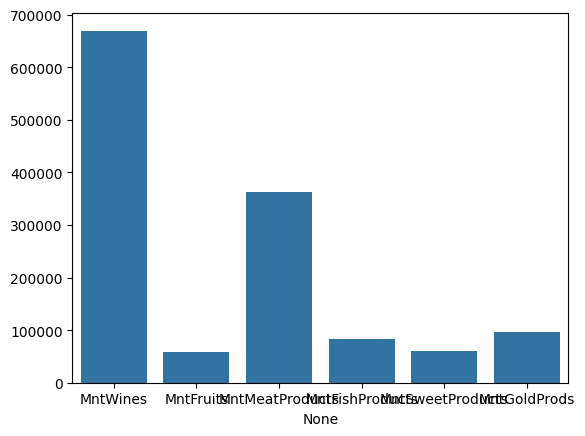

In [ ]:
# we can take it as Discrete ND and choose bar plot
sns.barplot(x=top_performing_products.index, y=top_performing_products.values)

In [ ]:
lowest_revenue = top_performing_products.idxmin()
print(lowest_revenue)

MntFruits


<Axes: xlabel='MntFruits', ylabel='None'>

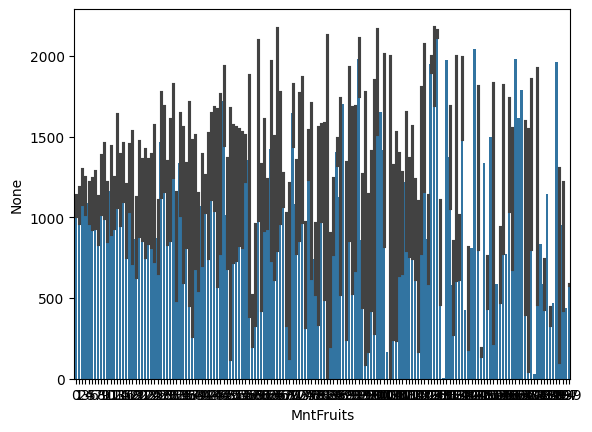

In [ ]:
sns.barplot(x=marketingData[lowest_revenue], y=marketingData.index)

<Axes: xlabel='age', ylabel='Response'>

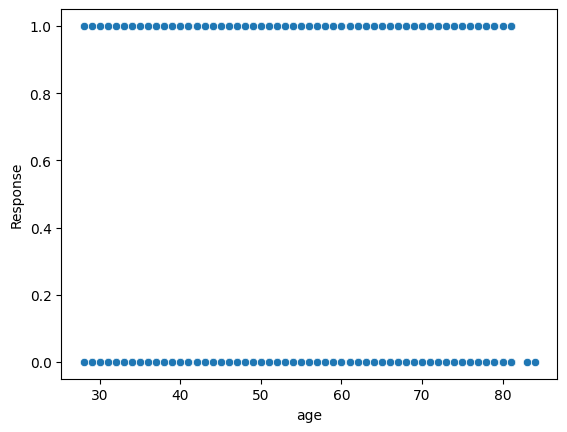

In [ ]:
#Examine if there is a correlation between customers' age and the acceptance rate of the last campaign
# Here the las campaign is Response
sns.scatterplot(x='age', y='Response', data=marketingData)

In [ ]:
corr, pvalue = pearsonr(marketingData['age'], marketingData['Response'])
print(corr, pvalue)
if pvalue <= SL:
  print("linear Relationship")
else:
  print("No linear Relationship")

-0.017811428002717247 0.4068252975446546
No linear Relationship


In [ ]:
# Determine the country with the highest number of customers who accepted the last campaign
# data = pd.read_csv("marketing_data.csv")
marketingData['Country'].value_counts()
country_campaign = marketingData.groupby('Country')['Response'].sum().sort_values(ascending=False)
print(country_campaign)

Country
SP     173
SA      52
CA      38
AUS     23
GER     17
IND     13
US      13
ME       2
Name: Response, dtype: int64


<Axes: xlabel='Country'>

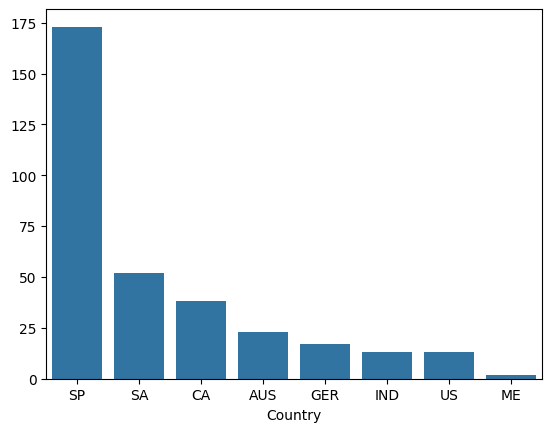

In [ ]:
sns.barplot(x=country_campaign.index, y=country_campaign.values)

<Axes: xlabel='total_children', ylabel='total_spending'>

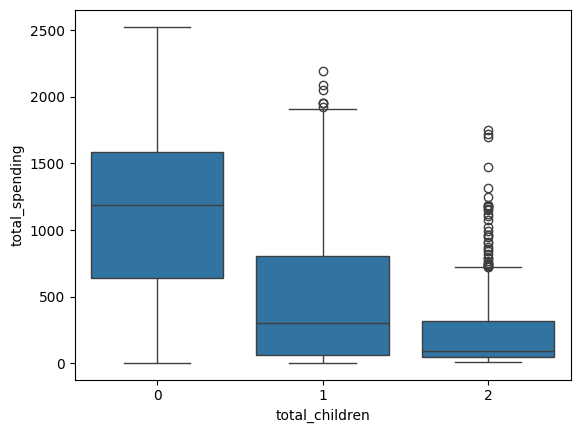

In [ ]:
#Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
sns.boxplot(x='total_children', y='total_spending', data=marketingData)

### **ouput : Since we can see the outliers, we need to eliminate by using Hypothesis (Normality/Parametric/ Non-parametric)**


In [ ]:
# Analyze the educational background of customers who lodged complaints in the last two years
# Complain: 1 if customer complained in the last 2 years
education_complaints = marketingData[marketingData['Complain'] == 1].groupby('Education')['Complain'].count()
print(education_complaints)

Education
2n Cycle       3
Graduation    13
Master         2
PhD            1
Name: Complain, dtype: int64


<Axes: xlabel='Education'>

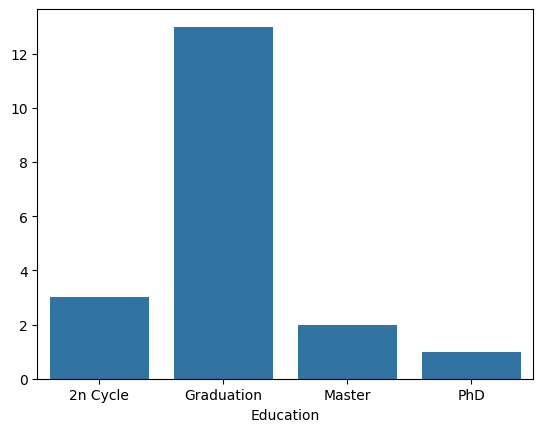

In [ ]:
# choose bar plot for categorical data
sns.barplot(x=education_complaints.index, y=education_complaints.values)

Outcome: Complaints are raised maximum by **Graduation** customer

In [ ]:
# Apply ordinal and one-hot encoding based on the various types of categorical

education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'Phd': 4
}
marketingData['Education'] = marketingData['Education'].map(education_order)

df1 = pd.get_dummies(marketingData['Marital_Status'] , dtype=int)
df2 = pd.get_dummies(marketingData['Country'] , dtype=int)
marketingData = pd.concat([marketingData, df1, df2], axis=1)
marketingData.drop(['Marital_Status', 'Country'], axis=1, inplace=True)

In [ ]:
marketingData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2171 entries, 0 to 2239
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2171 non-null   int64  
 1   Year_Birth            2171 non-null   int64  
 2   Education             1708 non-null   float64
 3   Income                2171 non-null   int64  
 4   Kidhome               2171 non-null   int64  
 5   Teenhome              2171 non-null   int64  
 6   Dt_Customer           2171 non-null   object 
 7   Recency               2171 non-null   int64  
 8   MntWines              2171 non-null   int64  
 9   MntFruits             2171 non-null   int64  
 10  MntMeatProducts       2171 non-null   int64  
 11  MntFishProducts       2171 non-null   int64  
 12  MntSweetProducts      2171 non-null   int64  
 13  MntGoldProds          2171 non-null   int64  
 14  NumDealsPurchases     2171 non-null   int64  
 15  NumWebPurchases       2171

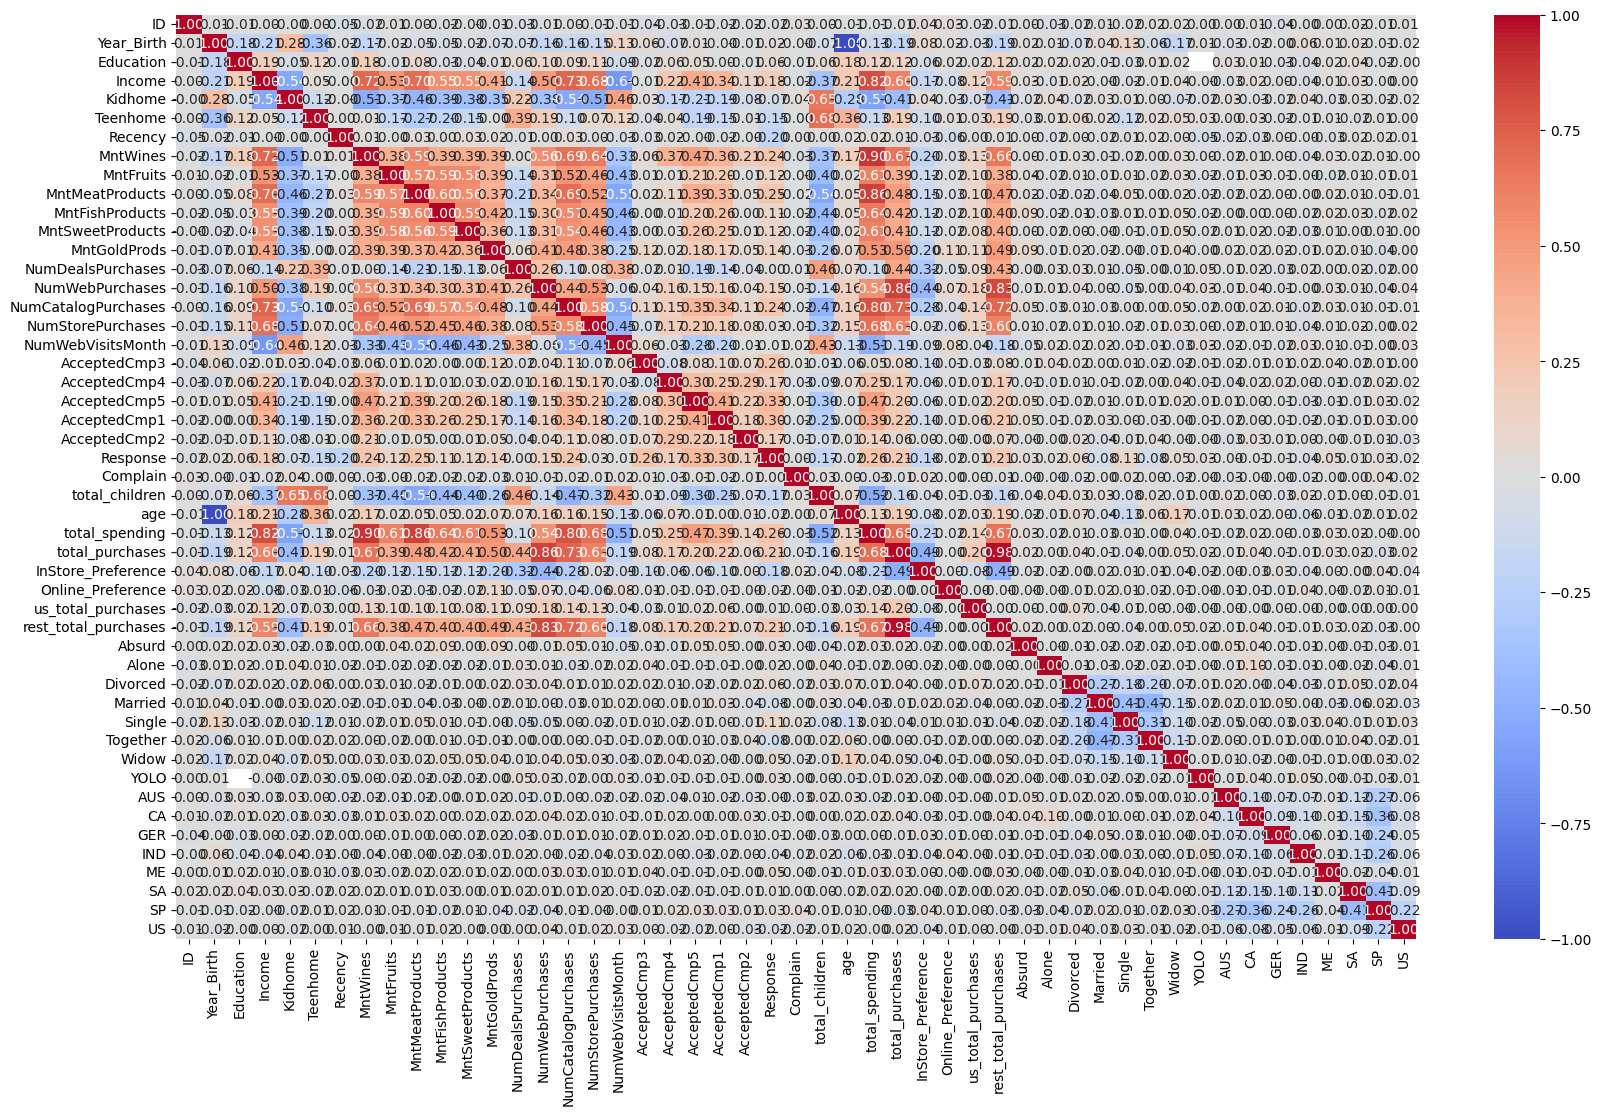

In [ ]:
#  Generate a heatmap to illustrate the correlation between different pairs of variables
df = pd.DataFrame(marketingData)
df = df.select_dtypes(include=['int64', 'float64'])
corr = df.corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()